# Decision Tree Loan Approval

This notebook follows the full decision tree workflow: dataset inspection, target analysis, preprocessing, baseline modeling, decision tree training, evaluation, feature importance, and a smaller-tree comparison.


## 1. Import libraries


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Load the loan approval dataset


In [2]:
df = pd.read_csv("loan_data.csv")

## 3. Display the first five rows and dataset shape


In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 4. Check column names, data types, and basic info


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## 5. Check for missing values


In [5]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

## 6. Check for duplicate rows


In [6]:
df.duplicated().sum()

np.int64(0)

## 7. Examine the target distribution


In [7]:
target = df["loan_status"].value_counts()
target

loan_status
0    35000
1    10000
Name: count, dtype: int64

## 8. Convert target counts into percentages


In [8]:
target_parc = df["loan_status"].value_counts(normalize=True) * 100
target_parc

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

## 9. Identify numerical and categorical features


In [9]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
numerical_features.remove("loan_status")  # Remove target variable from numerical featuresq 
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorical Features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


## 10. Create visualizations to compare features with approval


Text(0.5, 1.0, 'Distribution of Loan Status')

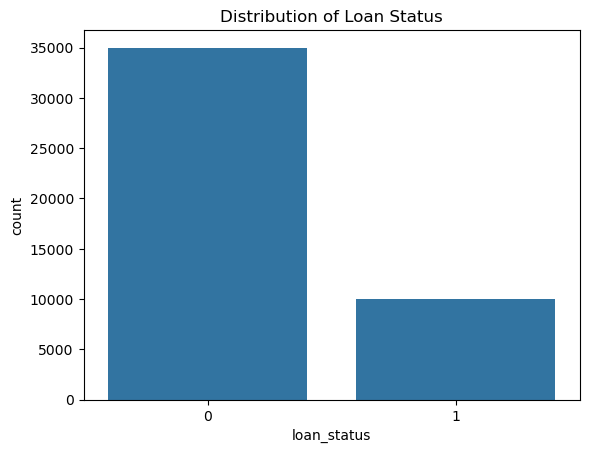

In [10]:
sns.countplot(data=df, x='loan_status')
plt.title('Distribution of Loan Status')

([<matplotlib.axis.XTick at 0x288bfb2bc50>,
 [Text(0, 0, 'Not Approved'), Text(1, 0, 'Approved')])

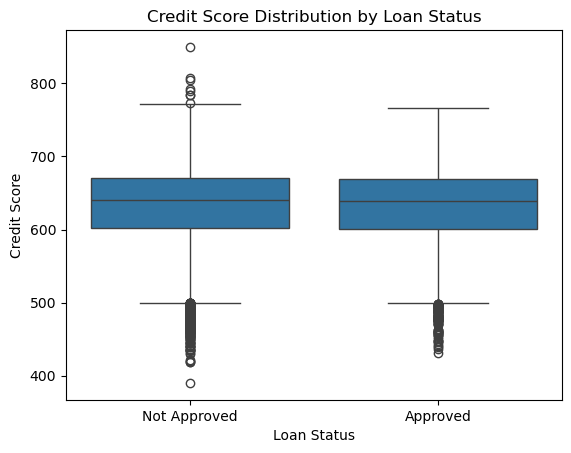

In [11]:
sns.boxplot(data = df , x = "loan_status", y = "credit_score")
plt.title('Credit Score Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Credit Score')
plt.xticks([0, 1], ['Not Approved', 'Approved'])

## 11. Separate features X and target y


In [12]:
X = df.drop("loan_status" , axis = 1 )
y = df["loan_status"]
X.head() 
y.head()

0    1
1    0
2    1
3    1
4    1
Name: loan_status, dtype: int64

## 12. Remove applicant_id from X


## 13. Split the data into training and testing sets with stratify


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 14. Check the train/test target distribution


In [14]:
percent_train = y_train.value_counts(normalize=True) * 100
percent_test = y_test.value_counts(normalize=True) * 100

print("Training Set Distribution:\n", percent_train)
print("\nTesting Set Distribution:\n", percent_test)

Training Set Distribution:
 loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

Testing Set Distribution:
 loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


## 15. Build numerical preprocessing pipeline


In [15]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())    
])

## 16. Build categorical preprocessing pipeline


In [16]:
categorical_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

## 17. Combine preprocessing with ColumnTransformer


In [17]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

## 18. Create and train a baseline DummyClassifier


In [18]:
baseline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", DummyClassifier(strategy="most_frequent"))])

baseline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 19. Make baseline predictions and evaluate baseline


In [19]:
baseline_predictions = baseline.predict(X_test)

print(classification_report(y_test, baseline_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88      7000
           1       0.00      0.00      0.00      2000

    accuracy                           0.78      9000
   macro avg       0.39      0.50      0.44      9000
weighted avg       0.60      0.78      0.68      9000



## 20. Create the Decision Tree pipeline


In [20]:
disc_tree = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=42))])

## 21. Train the Decision Tree model


In [21]:
disc_tree.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 22. Make predictions on the test set


In [22]:
dis_predictions = disc_tree.predict(X_test)

## 23. Calculate accuracy, precision, recall, and F1 score


In [23]:
print(classification_report(y_test, dis_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7000
           1       0.77      0.78      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000



## 24. Display the classification report


## 25. Create the confusion matrix


In [24]:
conf_matrix = confusion_matrix(y_test, dis_predictions)
conf_matrix

array([[6546,  454],
       [ 447, 1553]])

## 26. Visualize the confusion matrix with a heatmap


<Axes: >

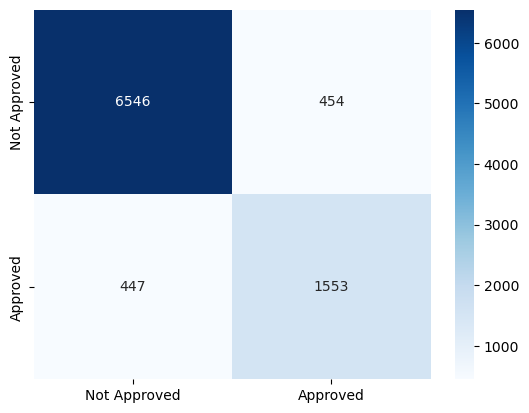

In [25]:
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Approved", "Approved"], yticklabels=["Not Approved", "Approved"])

## 27. Check Decision Tree feature importance


In [26]:
tree_model = disc_tree.named_steps["classifier"]

feature_names = disc_tree.named_steps["preprocessor"].get_feature_names_out()

importances = tree_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
26,cat__previous_loan_defaults_on_file_Yes,0.294187
4,num__loan_int_rate,0.160442
5,num__loan_percent_income,0.152121
1,num__person_income,0.138318
7,num__credit_score,0.049029
18,cat__person_home_ownership_RENT,0.036347
3,num__loan_amnt,0.031607
0,num__person_age,0.021467
2,num__person_emp_exp,0.018293
6,num__cb_person_cred_hist_length,0.018226


## 28. Train a smaller tree using max_depth


In [34]:
smallTree = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=4, random_state=42))
])

smallTree.fit(X_train, y_train)
small_tree_predictions = smallTree.predict(X_test)

## 29. Compare the full tree and smaller tree


In [37]:
print("Full Decision Tree")
print(classification_report(y_test, dis_predictions, zero_division=0))

print("Small Decision Tree")
print(classification_report(y_test, small_tree_predictions, zero_division=0))

print ("dummy_predictions")
print(classification_report(y_test, baseline_predictions, zero_division=0))


Full Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7000
           1       0.77      0.78      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000

Small Decision Tree
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7000
           1       0.86      0.71      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.89      0.84      0.86      9000
weighted avg       0.91      0.91      0.91      9000

dummy_predictions
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      7000
           1       0.00      0.00      0.00      2000

    accuracy                           0.78      9000
   macro avg       0.39      0.50      0.44      9000
weighted avg     

## 30. Final observations and what I learned

1. Did the Decision Tree perform better than the DummyClassifier? How do you know?

   Answer: yes by about 30%

2. Which metric is most important for this loan approval problem: accuracy, precision, recall, or F1 score? Why?

   Answer:Precision for approval is the most important because approving the wrong applicants can be financially risky.

3. Was the target balanced or imbalanced? How could that affect the model evaluation?

   Answer: The target was imbalanced. This can cause the model to be better at predicting one class over the other, which is what we see.

4. Which features were most important in the full Decision Tree model?

   Answer: The most important features were previous loan defaults, loan interest rate, loan percent income, person income, and credit score.

5. Did the full Decision Tree seem better at predicting rejected loans or approved loans?

   Answer: It is better at prediciting rejected loans 

6. What did the confusion matrix show about the model's mistakes?

   Answer: The confusion matrix shows that the model has a harder time recognizing approved loans than rejected loans.

7. What changed when you trained a smaller tree with `max_depth=4`?

   Answer: The smaller tree limited how deep the Decision Tree could grow. Its accuracy was slightly higher at about 91%, and its precision for approved loans improved, but its recall for approved loans dropped.

8. Did the smaller tree perform better or worse than the full tree? Which one would you trust more and why?

   Answer: The smaller tree performed slightly better by accuracy, about 91% compared to 90%. I might trust the smaller tree more because it is simpler, easier to explain, and may overfit less than the full tree.

9. Why can a full Decision Tree overfit?

   Answer: A full Decision Tree can overfit because it can keep splitting until it learns very specific patterns in the training data. This can make it perform well on training data but worse on new data.

10. What is one thing you could try next to improve the model?

    Answer:I could try tuning max_depth and other tree settings, such as min_samples_split or min_samples_leaf, to find a better balance between performance and overfitting.